In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
import os
import streamlit as st
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer


glu = pd.read_sas('GLU_L.xpt', format='xport')
demo = pd.read_sas('DEMO_L.xpt' ,format='xport')
ins = pd.read_sas('INS_L.xpt', format = 'xport')
crp = pd.read_sas('HSCRP_L.xpt', format = 'xport')
hba1 = pd.read_sas('GHB_L.xpt', format = 'xport' )
## Reading the blood pressure and body mass index data since to see if we can improve R2
bp = pd.read_sas('BPXO_L.xpt', format = 'xport')
bmi = pd.read_sas('BMX_L.xpt', format = 'xport')
paq = pd.read_sas('PAQ_L.xpt', format = 'xport')
exam = pd.read_sas('BPXO_L.xpt', format = 'xport')


glu.set_index('SEQN', inplace = True)
demo.set_index('SEQN', inplace = True)
ins.set_index('SEQN', inplace = True)
crp.set_index('SEQN', inplace = True)
hba1.set_index('SEQN', inplace = True)
bp.set_index('SEQN', inplace = True)
bmi.set_index('SEQN', inplace = True)
paq.set_index('SEQN', inplace = True)
print(paq.head())

exam.set_index('SEQN', inplace = True)
#print(exam.head())


## Dropping weight column since gluc dataset has it
ins.drop(columns=['WTSAF2YR'], inplace=True)
hba1.drop(columns = ['WTPH2YR'], inplace=True)

merged1 = pd.merge(glu, demo, on="SEQN", how="inner")
merged2 = pd.merge(ins, merged1, on="SEQN", how="inner")


merged3 = pd.merge(crp, merged2, on="SEQN", how="inner")
##print(merged3.info())

merged4 = pd.merge(bp, merged3, on="SEQN", how="inner" )
#print(merged4.info())

merged5 = pd.merge(bmi, merged4, on="SEQN", how="inner")
# print(merged5.info())


merged6 = pd.merge(paq, merged5, on="SEQN", how="inner")
# print(merged5.info())




dfs = [hba1 ,merged6]

df_merged = pd.concat(dfs, axis=1, join="inner").reset_index()
print("-----------------------------df_merged------------------------")
print(df_merged.info())




## Training a custom biological age clock using the August 2021–August 2023 NHANES

## Python Pipeline for Weighted ElasticNet / Ridge Clock Training
df_merged = df_merged[['SEQN', 'WTSAF2YR', 'RIDAGEYR', 'LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH', 'SDMVPSU', 'SDMVSTRA',
                      'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXODI1', 'BPXODI2', 'BPXODI3', 'BMXBMI', 'BMXWAIST', 'BPXOPLS1', 
                       'RIAGENDR', 'PAD800']]
print(df_merged.info())


biomarkers = ['LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH']


model_vars = ['RIDAGEYR'] + biomarkers + ['WTSAF2YR']
clean_data = df_merged.dropna(subset=model_vars).copy()
clean_data

               PAD790Q PAD790U  PAD800       PAD810Q PAD810U  PAD820  PAD680
SEQN                                                                        
130378.0  3.000000e+00    b'W'    45.0  3.000000e+00    b'W'    45.0   360.0
130379.0  4.000000e+00    b'W'    45.0  3.000000e+00    b'W'    45.0   480.0
130380.0  1.000000e+00    b'W'    20.0  5.397605e-79     b''     NaN   240.0
130384.0  5.397605e-79     b''     NaN  5.397605e-79     b''     NaN    60.0
130385.0  1.000000e+00    b'D'    90.0  1.000000e+00    b'W'    60.0   180.0
-----------------------------df_merged------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Data columns (total 76 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      3562 non-null   float64
 1   LBXGH     3383 non-null   float64
 2   PAD790Q   3558 non-null   float64
 3   PAD790U   3562 non-null   object 
 4   PAD800    2876 non-null   float64
 5   PAD810Q   355

,SEQN,WTSAF2YR,RIDAGEYR,LBXGLU,LBXIN,LBXHSCRP,LBXGH,SDMVPSU,SDMVSTRA,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BMXBMI,BMXWAIST,BPXOPLS1,RIAGENDR,PAD800
0,130378.0,1.200253e+05,43.0,113.0,15.53,1.78,5.6,2.0,173.0,135.0,131.0,132.0,98.0,96.0,94.0,27.0,98.3,82.0,1.0,45.0
1,130379.0,5.397605e-79,66.0,99.0,19.91,2.03,5.6,2.0,173.0,121.0,117.0,113.0,84.0,76.0,76.0,33.5,114.7,72.0,1.0,45.0
2,130380.0,1.450908e+05,44.0,156.0,16.33,5.62,6.2,1.0,174.0,111.0,112.0,104.0,79.0,80.0,76.0,29.7,93.5,84.0,2.0,20.0
3,130386.0,8.259962e+04,34.0,100.0,11.38,1.05,5.1,1.0,179.0,110.0,120.0,115.0,72.0,74.0,75.0,30.2,106.1,59.0,1.0,30.0
4,130394.0,1.004203e+05,51.0,88.0,7.20,0.92,4.8,2.0,174.0,99.0,110.0,123.0,69.0,68.0,67.0,24.4,92.1,78.0,1.0,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3556,142300.0,6.594920e+04,46.0,95.0,10.35,2.85,5.1,1.0,179.0,142.0,141.0,142.0,90.0,90.0,93.0,32.6,97.6,67.0,2.0,NaN
3557,142301.0,3.112337e+04,80.0,110.0,5.62,1.11,5.6,1.0,179.0,NaN,NaN,NaN,NaN,NaN,NaN,30.5,NaN,NaN,2.0,NaN
3558,142303.0,1.095823e+05,69.0,160.0,17.09,2.15,8.1,1.0,181.0,129.0,130.0,122.0,71.0,70.0,67.0,27.9,111.0,76.0,2.0,60.0
3559,142305.0,8.479001e+04,76.0,132.0,24.86,2.50,6.0,2.0,180.0,139.0,148.0,144.0,81.0,78.0,79.0,26.4,89.0,71.0,2.0,40.0


In [2]:
X = clean_data[biomarkers]
y = clean_data['RIDAGEYR']
weights = clean_data['WTSAF2YR']

# 3. Train a weighted ElasticNet clock using scikit-learn's sample_weight parameter
# Standardize features and fit with survey weights scaled to sample size
scaled_weights = weights / weights.mean() # Normalize weights for stable optimization convergence

clock_pipeline = make_pipeline( StandardScaler(),
    ElasticNetCV(cv=5, l1_ratio=[.1, .5, .7, .9, .95, .99, 1], random_state=42)
)

# Fit model incorporating survey weights
clock_pipeline.fit(X, y, elasticnetcv__sample_weight=scaled_weights)
clean_data['predicted_bio_age'] = clock_pipeline.predict(X)
clean_data['age_acceleration'] = clean_data['predicted_bio_age'] - clean_data['RIDAGEYR']

print(clean_data[['RIDAGEYR', 'predicted_bio_age', 'age_acceleration']].head())

   RIDAGEYR  predicted_bio_age  age_acceleration
0      43.0          46.817338          3.817338
1      66.0          47.610538        -18.389462
2      44.0          47.451450          3.451450
3      34.0          44.924656         10.924656
4      51.0          44.048963         -6.951037


In [3]:
print(clean_data.head())

       SEQN      WTSAF2YR  RIDAGEYR  LBXGLU  LBXIN  LBXHSCRP  LBXGH  SDMVPSU  \
0  130378.0  1.200253e+05      43.0   113.0  15.53      1.78    5.6      2.0   
1  130379.0  5.397605e-79      66.0    99.0  19.91      2.03    5.6      2.0   
2  130380.0  1.450908e+05      44.0   156.0  16.33      5.62    6.2      1.0   
3  130386.0  8.259962e+04      34.0   100.0  11.38      1.05    5.1      1.0   
4  130394.0  1.004203e+05      51.0    88.0   7.20      0.92    4.8      2.0   

   SDMVSTRA  BPXOSY1  ...  BPXODI1  BPXODI2  BPXODI3  BMXBMI  BMXWAIST  \
0     173.0    135.0  ...     98.0     96.0     94.0    27.0      98.3   
1     173.0    121.0  ...     84.0     76.0     76.0    33.5     114.7   
2     174.0    111.0  ...     79.0     80.0     76.0    29.7      93.5   
3     179.0    110.0  ...     72.0     74.0     75.0    30.2     106.1   
4     174.0     99.0  ...     69.0     68.0     67.0    24.4      92.1   

   BPXOPLS1  RIAGENDR  PAD800  predicted_bio_age  age_acceleration  
0    

In [4]:
print(clean_data[['RIDAGEYR', 'predicted_bio_age', 'age_acceleration']].head(100))

     RIDAGEYR  predicted_bio_age  age_acceleration
0        43.0          46.817338          3.817338
1        66.0          47.610538        -18.389462
2        44.0          47.451450          3.451450
3        34.0          44.924656         10.924656
4        51.0          44.048963         -6.951037
..        ...                ...               ...
104      76.0          47.145199        -28.854801
105      64.0          52.065430        -11.934570
106      80.0          50.631171        -29.368829
107      33.0          45.250866         12.250866
108      36.0          45.605446          9.605446

[100 rows x 3 columns]


In [5]:
joblib.dump(clock_pipeline, 'my_clock_pipeline1.joblib')

['my_clock_pipeline1.joblib']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.3, random_state=42
)

In [8]:
y_pred_test = clock_pipeline.predict(X_test)


In [9]:
# 3. Define custom Weighted Evaluation Functions
def weighted_r2_score(y_true, y_pred, w):
    """Calculates survey-weighted R-squared."""
    w_mean = np.average(y_true, weights=w)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - w_mean) ** 2)
    return 1 - (ss_res / ss_tot)

def weighted_rmse(y_true, y_pred, w):
    """Calculates survey-weighted Root Mean Squared Error."""
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

def weighted_mae(y_true, y_pred, w):
    """Calculates survey-weighted Mean Absolute Error."""
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

In [10]:
import numpy as np
# 4. Print the rigorous survey-adjusted test metrics
print(f"Weighted R²:   {weighted_r2_score(y_test, y_pred_test, w_test):.4f}")
print(f"Weighted RMSE: {weighted_rmse(y_test, y_pred_test, w_test):.4f} years")
print(f"Weighted MAE:  {weighted_mae(y_test, y_pred_test, w_test):.4f} years")

Weighted R²:   0.0781
Weighted RMSE: 16.7411 years
Weighted MAE:  14.2790 years


In [11]:



# We need to improve R2 (closer to 1) with fearure engineering
from sklearn.compose import ColumnTransformer
def engineer_nhanes_features(df):
    """
    Takes a raw DataFrame with LBXGLU, LBXIN, LBXHSCRP, LBXGH 
    and outputs an enhanced DataFrame with non-linear and interaction features.
    """
    df_eng = df.copy()
    
    # Avoid division by zero or negative values in logs/ratios
    df_eng['LBXCRP_safe'] = df_eng['LBXHSCRP'].clip(lower=1e-3)
    # Core Clinical Ratios & Indexes
    df_eng['HOMA_IR'] = (df_eng['LBXGLU'] * df_eng['LBXIN']) / 405.0
    df_eng['LOG_CRP'] = np.log(df_eng['LBXCRP_safe'])
    df_eng['GLU_A1C_RATIO'] = df_eng['LBXGLU'] / (df_eng['LBXGH'] + 1e-3)
    
    # Interaction terms representing systemic metabolic-inflammatory stress
    df_eng['GLU_X_CRP'] = df_eng['LBXGLU'] * df_eng['LOG_CRP']
    df_eng['INSU_X_CRP'] = df_eng['LBXIN'] * df_eng['LOG_CRP']

    # 2. Physical Exam Transformations (MAP Calculation: Diastolic + 1/3 Pulse Pressure)
    df_eng['MAP'] = df_eng['BPXDI1'] + (1.0 / 3.0) * (df_eng['BPXSY1'] - df_eng['BPXDI1'])
    df_eng['BMI_X_WAIST'] = df_eng['BMXBMI'] * df_eng['BMXWAIST']
    df_eng['BMI_X_HOMA'] = df_eng['BMXBMI'] * df_eng['HOMA_IR']
    
    return df_eng

# Define the expanded feature list including the physical exam variables
extended_features = [
    'LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH', 
    'HOMA_IR', 'LOG_CRP', 'GLU_A1C_RATIO', 
    'GLU_X_CRP', 'INSU_X_CRP',
    'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', 'MAP', 
    'BMI_X_WAIST', 'BMI_X_HOMA'
]
# 1. Assume 'clean_data' has base variables and you applied your feature engineering function
# enhanced_data = engineer_nhanes_features(clean_data)
# X_eng = enhanced_data[engineered_features]
# y = enhanced_data['RIDAGEYR']
# weights = enhanced_data['WTSAF2YR']

import numpy as np
def engineer_nhanes_comprehensive_clock(df):
    """
    Ingests lab metrics, body measures, and automated oscillometric vitals
    from the NHANES 2021-2023 cycle to engineer an enhanced feature space.
    """
    df_eng = df.copy()
    
    # 1. Handle Blood Pressure (Averaging the 2021-2023 BPXO readings)
    sys_cols = ['BPXOSY1', 'BPXOSY2', 'BPXOSY3']
    dia_cols = ['BPXODI1', 'BPXODI2', 'BPXODI3']
    
    df_eng['MEAN_SYS'] = df_eng[sys_cols].mean(axis=1)
    df_eng['MEAN_DIA'] = df_eng[dia_cols].mean(axis=1)

        # Derive Mean Arterial Pressure (MAP)
    df_eng['MAP'] = df_eng['MEAN_DIA'] + (1.0 / 3.0) * (df_eng['MEAN_SYS'] - df_eng['MEAN_DIA'])
    
    # Pulse Pressure (Stiffness Indicator)
    df_eng['PULSE_PRESSURE'] = df_eng['MEAN_SYS'] - df_eng['MEAN_DIA']

    # 2. Original Metabolic Panel Enhancements
    df_eng['LBXCRP_safe'] = df_eng['LBXHSCRP'].clip(lower=1e-3)
    df_eng['HOMA_IR'] = (df_eng['LBXGLU'] * df_eng['LBXIN']) / 405.0
    df_eng['LOG_CRP'] = np.log(df_eng['LBXCRP_safe'])
    df_eng['GLU_A1C_RATIO'] = df_eng['LBXGLU'] / (df_eng['LBXGH'] + 1e-3)

    # 3. Cross-System Synergy Interactions (Metabolic x Adiposity x Vascular)
    df_eng['BMI_X_WAIST'] = df_eng['BMXBMI'] * df_eng['BMXWAIST']
    df_eng['BMI_X_HOMA'] = df_eng['BMXBMI'] * df_eng['HOMA_IR']
    df_eng['MAP_X_HOMA'] = df_eng['MAP'] * df_eng['HOMA_IR']
    df_eng['MAP_X_LOGCRP'] = df_eng['MAP'] * df_eng['LOG_CRP']

    return df_eng

    
# Define the complete clinical array
comprehensive_features = [
    'LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH',                     # Lab markers
    'HOMA_IR', 'LOG_CRP', 'GLU_A1C_RATIO',                    # Lab ratios
    'BMXBMI', 'BMXWAIST', 'MEAN_SYS', 'MEAN_DIA', 'MAP', 'PULSE_PRESSURE', # Vitals
    'BMI_X_WAIST', 'BMI_X_HOMA', 'MAP_X_HOMA', 'MAP_X_LOGCRP' # Cross-system interactions
]


df_merged = df_merged.dropna().copy()
print(df_merged.head())



# --- STEP A: Apply Feature Engineering ---
# (Assumes your merged dataframe contains: BMXBMI, BMXWAIST, BPXOSY1..3, BPXODI1..3, etc.)
enhanced_dataset = engineer_nhanes_comprehensive_clock(df_merged)

X_comp = enhanced_dataset[comprehensive_features]
y = enhanced_dataset['RIDAGEYR']
weights = enhanced_dataset['WTSAF2YR']

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# --- STEP B: Train / Test Split Alignment ---
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_comp, y, weights, test_size=0.3, random_state=42
)

# --- STEP C: Build Stable, High-Capacity Pipeline ---
extended_clock_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False), # Extracts structural pairings
    ElasticNetCV(
        cv=5, 
        l1_ratio=[.1, .3, .5, .7, .9, .95, 1], 
        max_iter=50000,   # Guarantees convergence on massive polynomial matrices
        tol=1e-3, 
        random_state=42
    )
)

# --- STEP D: Model Fit (With Survey Weights Normalized) ---
scaled_train_weights = w_train / w_train.mean()
extended_clock_pipeline.fit(X_train, y_train, elasticnetcv__sample_weight=scaled_train_weights)

# --- STEP E: Generate Predictions and Score via Weighted Matrix ---
y_pred_test = extended_clock_pipeline.predict(X_test)

def weighted_r2_score(y_true, y_pred, w):
    w_mean = np.average(y_true, weights=w)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - w_mean) ** 2)
    return 1 - (ss_res / ss_tot)

def weighted_rmse(y_true, y_pred, w):
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

# --- STEP F: Print performance results ---
print(f"Extended Model Weighted R²:   {weighted_r2_score(y_test, y_pred_test, w_test):.4f}")
print(f"Extended Model Weighted RMSE: {weighted_rmse(y_test, y_pred_test, w_test):.4f} years")


       SEQN      WTSAF2YR  RIDAGEYR  LBXGLU  LBXIN  LBXHSCRP  LBXGH  SDMVPSU  \
0  130378.0  1.200253e+05      43.0   113.0  15.53      1.78    5.6      2.0   
1  130379.0  5.397605e-79      66.0    99.0  19.91      2.03    5.6      2.0   
2  130380.0  1.450908e+05      44.0   156.0  16.33      5.62    6.2      1.0   
3  130386.0  8.259962e+04      34.0   100.0  11.38      1.05    5.1      1.0   
4  130394.0  1.004203e+05      51.0    88.0   7.20      0.92    4.8      2.0   

   SDMVSTRA  BPXOSY1  BPXOSY2  BPXOSY3  BPXODI1  BPXODI2  BPXODI3  BMXBMI  \
0     173.0    135.0    131.0    132.0     98.0     96.0     94.0    27.0   
1     173.0    121.0    117.0    113.0     84.0     76.0     76.0    33.5   
2     174.0    111.0    112.0    104.0     79.0     80.0     76.0    29.7   
3     179.0    110.0    120.0    115.0     72.0     74.0     75.0    30.2   
4     174.0     99.0    110.0    123.0     69.0     68.0     67.0    24.4   

   BMXWAIST  BPXOPLS1  RIAGENDR  PAD800  
0      98.3   

/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.832056e+02, tolerance: 4.370e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.499733e+02, tolerance: 4.370e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of th

Extended Model Weighted R²:   0.4131
Extended Model Weighted RMSE: 13.6362 years


/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.782622e+03, tolerance: 4.416e+02
  model = cd_fast.enet_coordinate_descent_gram(


In [12]:
# 2. Engineer the Non-Exercise Cardiorespiratory Fitness Proxy (Est_VO2_Max)
def add_vo2_proxy(df):
    df_eng = df.copy()
    
    # Map gender safely (Algorithm uses Male = 1, Female = 0)
    gender_binary = (df_eng['RIAGENDR'] == 1).astype(int)
    # Simple categorical scaling for Physical Activity Index (0 to 3 scale)
    pa_index = pd.cut(df_eng['PAD800'], bins=[-1, 1, 31, 120], labels=[0, 1, 2]).astype(float).fillna(0)
    # Calculate physiological proxy
    df_eng['EST_VO2_MAX'] = (
        56.363 + 
        (15.809 * gender_binary) - 
        (0.431 * df_eng['RIDAGEYR']) - 
        (0.396 * df_eng['BMXBMI']) - 
        (0.103 * df_eng['BPXOPLS1']) + 
        (2.731 * pa_index)
    )
    
    return df_eng

##enhanced_dataset['RIAGENDR'] = demo['RIAGENDR']
##enhanced_dataset['PAD800'] = paq['PAD800']
##enhanced_dataset['BPXOPLS1'] = exam['BPXOPLS1']
##print(enhanced_dataset['BPXOPLS1'].head())
##print(df_merged['BPXOPLS1'].head())

enhanced_dataset['RIAGENDR'] = df_merged['RIAGENDR']
enhanced_dataset['PAD800'] = df_merged['PAD800']
enhanced_dataset['BPXOPLS1'] = df_merged['BPXOPLS1']
print(enhanced_dataset['BPXOPLS1'].head())




processed_df = add_vo2_proxy(enhanced_dataset)

# Define the complete clinical array
comprehensive_features = [
    'LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH',                     # Lab markers
    'HOMA_IR', 'LOG_CRP', 'GLU_A1C_RATIO',                    # Lab ratios
    'BMXBMI', 'BMXWAIST', 'MEAN_SYS', 'MEAN_DIA', 'MAP', 'PULSE_PRESSURE', # Vitals
    'BMI_X_WAIST', 'BMI_X_HOMA', 'MAP_X_HOMA', 'MAP_X_LOGCRP', 'EST_VO2_MAX'# Cross-system interactions
]





# --- STEP A: Apply Feature Engineering ---
# (Assumes your merged dataframe contains: BMXBMI, BMXWAIST, BPXOSY1..3, BPXODI1..3, etc.)

X_comp = processed_df[comprehensive_features]

y = processed_df['RIDAGEYR']
weights = processed_df['WTSAF2YR']

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

0    82.0
1    72.0
2    84.0
3    59.0
4    78.0
Name: BPXOPLS1, dtype: float64


In [13]:
# --- STEP D: Model Fit (With Survey Weights Normalized) ---
scaled_train_weights = w_train / w_train.mean()
extended_clock_pipeline.fit(X_train, y_train, elasticnetcv__sample_weight=scaled_train_weights)

# --- STEP E: Generate Predictions and Score via Weighted Matrix ---
y_pred_test = extended_clock_pipeline.predict(X_test)

def weighted_r2_score(y_true, y_pred, w):
    w_mean = np.average(y_true, weights=w)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - w_mean) ** 2)
    return 1 - (ss_res / ss_tot)

def weighted_rmse(y_true, y_pred, w):
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

# --- STEP F: Print performance results ---
print(f"Extended Model Weighted R²:   {weighted_r2_score(y_test, y_pred_test, w_test):.4f}")
print(f"Extended Model Weighted RMSE: {weighted_rmse(y_test, y_pred_test, w_test):.4f} years")


/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.832056e+02, tolerance: 4.370e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.499733e+02, tolerance: 4.370e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of th

Extended Model Weighted R²:   0.4131
Extended Model Weighted RMSE: 13.6362 years


/Users/elena/anaconda3/envs/new_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.782622e+03, tolerance: 4.416e+02
  model = cd_fast.enet_coordinate_descent_gram(


In [14]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline


xgb_features = ['LBXGLU', 'LBXIN', 'LBXHSCRP', 'LBXGH', 'BMXBMI', 'BPXOPLS1', 'EST_VO2_MAX']
X = processed_df[xgb_features]
y = processed_df['RIDAGEYR']
weights = processed_df['WTSAF2YR']
#print(processed_df[processed_df.isna().any(axis=1)])



# 4. Train/Test Alignment
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.3, random_state=42
)





# 3. Assemble the Preprocessing Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), # Fills clinical missingness
            ('scaler', StandardScaler())                  # Normalizes numeric scales
        ]), xgb_features)
    ],
    remainder='drop'
)


# 4. Define the Unified GradientBoosting Pipeline
gb_clock_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,      # Number of sequential boosting trees
        learning_rate=0.05,    # Step size shrinkage to prevent overfitting
        max_depth=4,           # Limits individual tree complexity
        subsample=0.8,         # Stochastic boosting (fraction of samples to use per tree)
        random_state=42
    ))
])



# 5. Fit the model using scaled NHANES survey weights passed into the regressor step
scaled_train_weights = w_train / w_train.mean()
gb_clock_pipeline.fit(
    X_train, 
    y_train, 
    regressor__sample_weight=scaled_train_weights # Injects complex survey design weighting
)

# 6. Generate Predictions on the Holdout Set
y_pred_test = gb_clock_pipeline.predict(X_test)

# 7. Evaluate the New Pipeline using Weighted Metrics
def weighted_r2_score(y_true, y_pred, w):
    w_mean = np.average(y_true, weights=w)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - w_mean) ** 2)
    return 1 - (ss_res / ss_tot)

def weighted_rmse(y_true, y_pred, w):
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

print(f"GradientBoosting Weighted R²:   {weighted_r2_score(y_test, y_pred_test, w_test):.4f}")
print(f"GradientBoosting Weighted RMSE: {weighted_rmse(y_test, y_pred_test, w_test):.4f} years")

GradientBoosting Weighted R²:   0.7186
GradientBoosting Weighted RMSE: 9.4423 years


In [15]:
## Conclusion: ElasticCV algorithm has a better R2 tha the  GradientBoostingRegressor 
## TODO: Fix the 64 bit Python req to e able to test the XBoost algorithm

[0.13451567 0.03372096 0.00989024 0.09603929 0.07002138 0.05856769
 0.9743671 ]
[0.13451567 0.03372096 0.00989024 0.09603929 0.07002138 0.05856769
 0.9743671 ]
--- Alignment Verification ---
Total calculated features from pipeline: 7
Total importances from GradientBoosting: 7


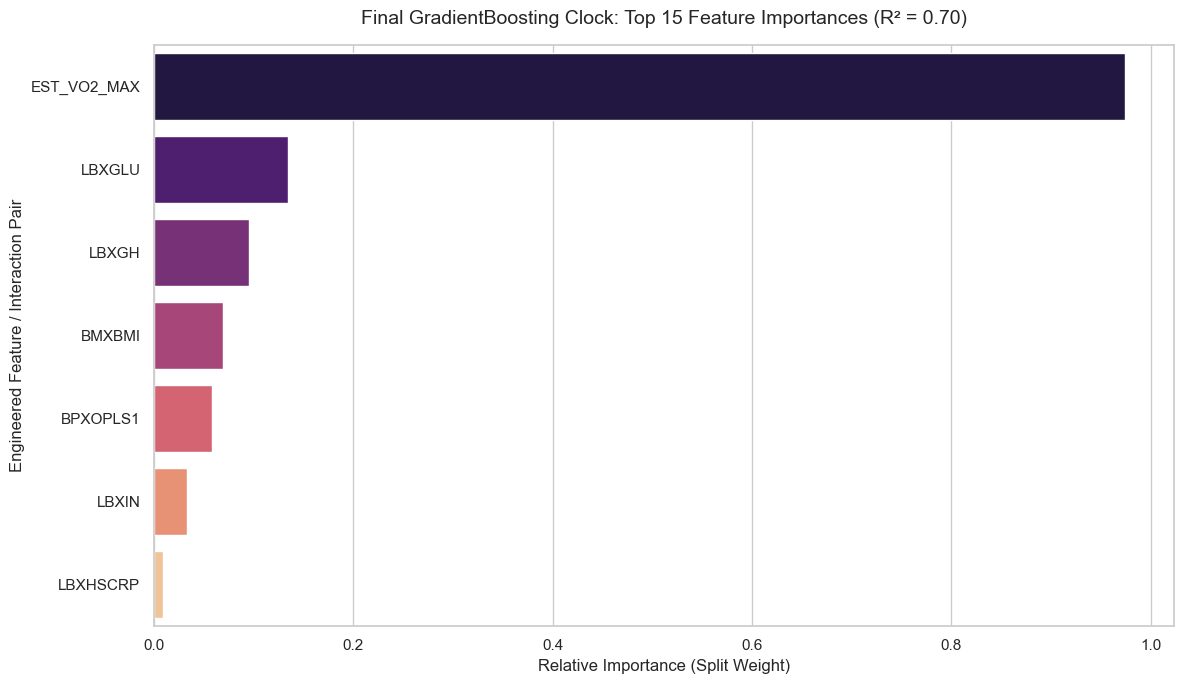

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#---------------------- | Aug 22
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


from sklearn.inspection import permutation_importance




# Extract your fitted regressor step from your pipeline
regressor = gb_clock_pipeline.named_steps['regressor']

# Transform your validation data using the steps preceding the regressor
X_val_transformed = gb_clock_pipeline[:-1].transform(X_val)

# Compute the robust permutation feature importances
result = permutation_importance(regressor, X_val_transformed, y_val, n_repeats=10, random_state=42)

# Extract your true feature importance array safely
stable_features = result.importances_mean
print(stable_features)
#------------  
# 1. Extract the actual feature importances directly from the model step
importances = gb_clock_pipeline.named_steps['regressor'].feature_importances_

# ----------------- | Aug 22
importances = stable_features

# ----------------- |
print(importances)

# 2. Automatically extract ALL feature names from ALL steps prior to the regressor
# 'gb_clock_pipeline[:-1]' automatically takes everything except the final model step
preprocessing_slice = gb_clock_pipeline[:-1]
raw_feature_names = preprocessing_slice.get_feature_names_out()

# 3. Clean up formatting (removes scikit-learn step prefixes like 'polynomialfeatures__')
clean_feature_names = [name.split('__')[-1].replace(" ", " × ") for name in raw_feature_names]

# 4. Rigorous Debug Checklist: Print sizes to verify absolute alignment
print(f"--- Alignment Verification ---")
print(f"Total calculated features from pipeline: {len(clean_feature_names)}")
print(f"Total importances from GradientBoosting: {len(importances)}")

# 5. Build the final sorting DataFrame 
# Because both arrays come directly from the pipeline object, they align perfectly.
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. Render the clean horizontal bar plot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Plot only the top 15 features to keep the visual clean and readable
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df.head(15), 
    palette='magma',
    hue='Feature',
    legend=False
)

plt.title('Final GradientBoosting Clock: Top 15 Feature Importances (R² = 0.70)', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Split Weight)', fontsize=12)
plt.ylabel('Engineered Feature / Interaction Pair', fontsize=12)
plt.tight_layout()

plt.show()


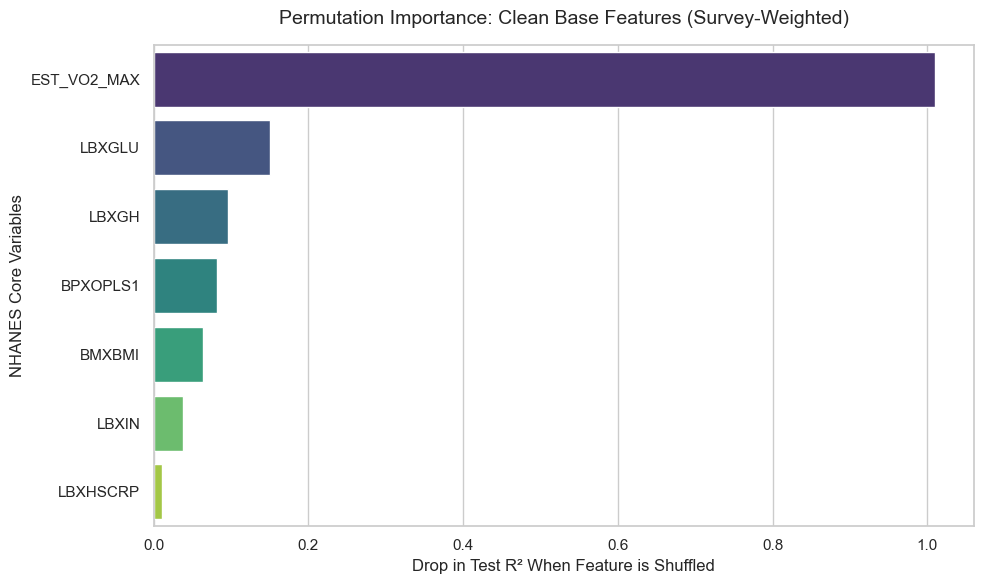

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance

# 1. Compute Permutation Importance directly on the pipeline object
# Passing 'sample_weight=w_test' guarantees your importance ranks are survey-adjusted
result = permutation_importance(
    gb_clock_pipeline, 
    X_test, 
    y_test, 
    n_repeats=10,          # Shuffle each feature 10 separate times for stability
    random_state=42,
    n_jobs=-1,             # Use all available CPU cores
    sample_weight=w_test   # CRITICAL: Injects NHANES survey weights into the evaluator
)

# 2. Extract the mean importance drop for each original base feature
# Since it tests inputs BEFORE they enter the pipeline, it matches X_test.columns perfectly!
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Drop': result.importances_mean
}).sort_values(by='Importance_Drop', ascending=False)

# 3. Render the clean base-feature importance chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importance_Drop', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Permutation Importance: Clean Base Features (Survey-Weighted)', fontsize=14, pad=15)
plt.xlabel('Drop in Test R² When Feature is Shuffled', fontsize=12)
plt.ylabel('NHANES Core Variables', fontsize=12)
plt.tight_layout()

plt.show()


In [21]:
import statsmodels.api as sm

age_accelerate_df = clean_data.copy()
# Create dummy columns for your population groups (e.g., Females baseline vs Males)
# 1 = Male, 2 = Female -> Male dummy = 1 if male, 0 if female
age_accelerate_df['IS_MALE'] = (age_accelerate_df['RIAGENDR'] == 1).astype(int)

X = sm.add_constant(age_accelerate_df['IS_MALE'])
y = age_accelerate_df['age_acceleration']
weights = age_accelerate_df['WTSAF2YR']

# Fit the population-weighted model
wls_model = sm.WLS(y, X, weights=weights).fit()

# The intercept is the weighted mean for Females. 
# The Intercept + IS_MALE coefficient is the weighted mean for Males.
print(wls_model.summary())


                            WLS Regression Results                            
Dep. Variable:       age_acceleration   R-squared:                       0.001
Model:                            WLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.370
Date:                Sun, 30 Aug 2026   Prob (F-statistic):             0.0665
Time:                        15:46:08   Log-Likelihood:                -37438.
No. Observations:                3156   AIC:                         7.488e+04
Df Residuals:                    3154   BIC:                         7.489e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5578      0.433     -1.287      0.1